Copyright (c) 2024, Andrea Mastropietro. All rights reserved.

This code is licensed under the MIT License.

See the LICENSE file in the project root for more information.

## Shapley value variance study

In [ ]:
import os
os.environ["http_proxy"] = "http://web-proxy.informatik.uni-bonn.de:3128"
os.environ["https_proxy"] = "http://web-proxy.informatik.uni-bonn.de:3128"

In [2]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import random
import copy
import pickle
import yaml

# Numerical and scientific libraries
import numpy as np
from numpy.random import default_rng
import torch

# Visualization libraries
import matplotlib.pyplot as plt

# Graph and molecule processing libraries
from pysmiles import read_smiles

# DiffLinker-specific imports
from src.difflinker.datasets import get_dataloader
from src.difflinker.lightning import DDPM

# Project-specific imports
from src.utils import compute_hausdorff_distance_batch

# Progress bar
from tqdm.auto import tqdm
import sys

os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

with open('../config.yml', 'r') as file:
    config = yaml.safe_load(file)

checkpoint = "../" + config['CHECKPOINT']
DATA_FOLDER = "../" + config['DATA_FOLDER']
DATASET_NAME = config['DATASET_NAME']
keep_frames = int(config['KEEP_FRAMES'])
P = config['P']
device = config['DEVICE'] if torch.cuda.is_available() else 'cpu'
SEED = int(config['SEED'])
M = int(config['M'])
NUM_SAMPLES = int(config['NUM_SAMPLES'])
PARALLEL_STEPS = int(config['PARALLEL_STEPS'])
LOAD_INITIAL_DISTRIBUTION = config['LOAD_INITIAL_DISTRIBUTION']

print("Random seed: ", SEED)

model = DDPM.load_from_checkpoint(checkpoint, map_location=device)

model.val_data_prefix = DATASET_NAME

print(f"Running device: {device}")

model.data_path = DATA_FOLDER

model = model.eval().to(device)
model.setup(stage='val')
dataloader = get_dataloader(
    model.val_dataset,
    batch_size=1
)

Random seed:  42


/home/mastropietro/anaconda3/envs/diff_explainer/lib/python3.10/site-packages/lightning_fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
Lightning automatically

Running device: cuda:7


/home/mastropietro/Repositories/DiffSHAPer/src/difflinker/datasets.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.data = torch.load(dataset_path, map_location=dev

In [3]:
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
np.random.seed(SEED)
random.seed(SEED)

### Explainability with variance study

Loading initial distribution of noisy features and positions.


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/21 [00:00<?, ?it/s]

['Cc1ccc(CCNC(=O)NCCc2csc(N3CCCC3)n2)c(C)c1']


/tmp/ipykernel_2223789/2388605734.py:683: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /opt/conda/conda-bld/pytorch_1720538438429/work/aten/src/ATen/native/ReduceOps.cpp:1808.)
  sample_variances[i] = torch.var(torch.tensor(phi_sums_over_M[:i+1]), unbiased=True).item()


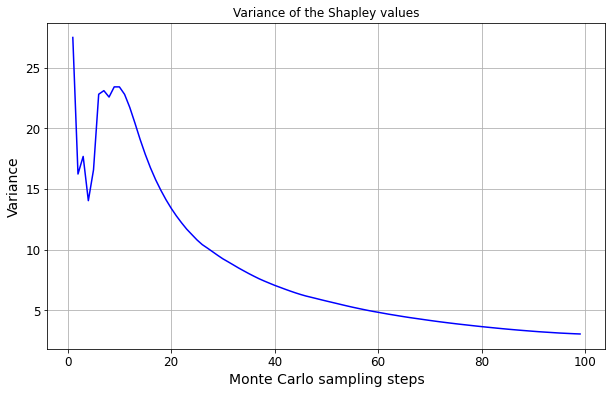

  0%|          | 0/20 [00:00<?, ?it/s]

['Cc1ccc(CCNC(=O)NCCc2csc(N3CCCC3)n2)c(C)c1']


/tmp/ipykernel_2223789/2388605734.py:683: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /opt/conda/conda-bld/pytorch_1720538438429/work/aten/src/ATen/native/ReduceOps.cpp:1808.)
  sample_variances[i] = torch.var(torch.tensor(phi_sums_over_M[:i+1]), unbiased=True).item()


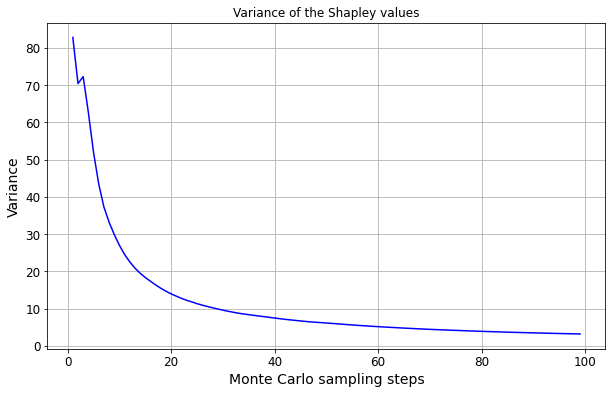

  0%|          | 0/21 [00:00<?, ?it/s]

['Cc1ccc(CCNC(=O)NCCc2csc(N3CCCC3)n2)c(C)c1']


/tmp/ipykernel_2223789/2388605734.py:683: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /opt/conda/conda-bld/pytorch_1720538438429/work/aten/src/ATen/native/ReduceOps.cpp:1808.)
  sample_variances[i] = torch.var(torch.tensor(phi_sums_over_M[:i+1]), unbiased=True).item()


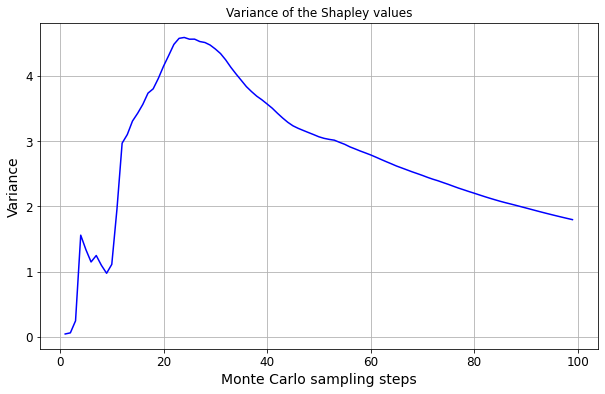

  0%|          | 0/19 [00:00<?, ?it/s]

['Cc1ccc(CCNC(=O)NCCc2csc(N3CCCC3)n2)c(C)c1']


/tmp/ipykernel_2223789/2388605734.py:683: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /opt/conda/conda-bld/pytorch_1720538438429/work/aten/src/ATen/native/ReduceOps.cpp:1808.)
  sample_variances[i] = torch.var(torch.tensor(phi_sums_over_M[:i+1]), unbiased=True).item()


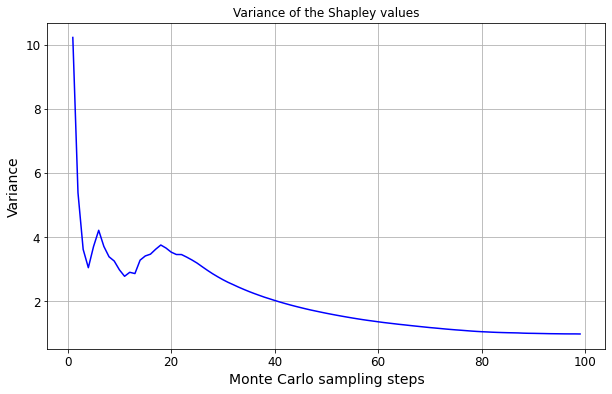

  0%|          | 0/19 [00:00<?, ?it/s]

['Cc1ccc(CCNC(=O)NCCc2csc(N3CCCC3)n2)c(C)c1']


/tmp/ipykernel_2223789/2388605734.py:683: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /opt/conda/conda-bld/pytorch_1720538438429/work/aten/src/ATen/native/ReduceOps.cpp:1808.)
  sample_variances[i] = torch.var(torch.tensor(phi_sums_over_M[:i+1]), unbiased=True).item()


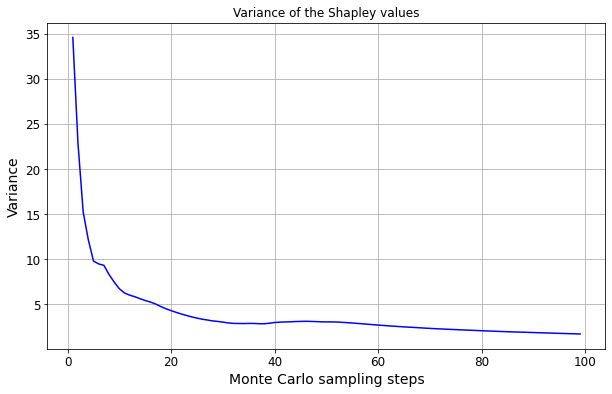

In [4]:
sampled = 0
start = 0

chain_with_full_fragments = None

# Create the folder if it does not exist

folder_save_path = f"../results/plots/variance_study_seed_{SEED}"

if not os.path.exists(folder_save_path):
    os.makedirs(folder_save_path)

data_list = []
for data in dataloader:

    if sampled < NUM_SAMPLES:
        data_list.append(data)
        sampled += 1

#determine max numebr of atoms of the molecules in the dataset. This is used to determine the size of the random noise, which we want to be equal for all molecules -> atoms not present in the molecule will be discarded using masks 
max_num_atoms = max(data["positions"].shape[1] for data in data_list)


pos_size = (data_list[0]["positions"].shape[0], max_num_atoms, data_list[0]["positions"].shape[2])
feature_size = (data_list[0]["one_hot"].shape[0], max_num_atoms, data_list[0]["one_hot"].shape[2])

INTIAL_DISTIBUTION_PATH = "../datasets/initial_distributions/seed_" + str(SEED)
noisy_features = None
noisy_positions = None
#check if the initial distribution of the noisy features and positions already exists, if not create it
if LOAD_INITIAL_DISTRIBUTION:

    # load initial distrubution of noisy features and positions
    print("Loading initial distribution of noisy features and positions.")
    noisy_features = torch.load(INTIAL_DISTIBUTION_PATH + "/noisy_features_seed_" + str(SEED) + ".pt", map_location=device, weights_only=True)
    noisy_positions = torch.load(INTIAL_DISTIBUTION_PATH + "/noisy_positions_seed_" + str(SEED) + ".pt", map_location=device, weights_only=True)

else:
    os.makedirs(INTIAL_DISTIBUTION_PATH, exist_ok=True)
    print("Creating initial distribution of noisy features and positions.")
    noisy_positions = torch.randn(pos_size, device=device)
    noisy_features = torch.randn(feature_size, device=device)


    #save the noisy positions and features on file .txt
    print("Saving noisy features and positions to .txt and .pt files.")
    noisy_positions_file = os.path.join(INTIAL_DISTIBUTION_PATH, "noisy_positions_seed_" + str(SEED) + ".txt")
    noisy_features_file = os.path.join(INTIAL_DISTIBUTION_PATH, "noisy_features_seed_" + str(SEED) + ".txt")

    with open(noisy_positions_file, "w") as f:
        f.write(str(noisy_positions))

    with open(noisy_features_file, "w") as f:
        f.write(str(noisy_features))

    #save the noisy positions and features on file .pt
    torch.save(noisy_positions, os.path.join(INTIAL_DISTIBUTION_PATH, "noisy_positions_seed_" + str(SEED) + ".pt"))
    torch.save(noisy_features, os.path.join(INTIAL_DISTIBUTION_PATH, "noisy_features_seed_" + str(SEED) + ".pt"))

for data_index, data in enumerate(tqdm(data_list)): 
        
        smile = data["name"][0]
        
        mol = read_smiles(smile)
        num_nodes = mol.number_of_nodes()
        
        num_edges = mol.number_of_edges()
        num_edges_directed = num_edges*2
        
        
        graph_density = num_edges_directed/(num_nodes*(num_nodes-1))
        max_number_of_nodes = num_edges + 1

        node_density = num_nodes/max_number_of_nodes

        node_edge_ratio = num_nodes/num_edges
        
        edge_node_ratio = num_edges/num_nodes
        
        if P == "graph_density":
            P = graph_density 
        elif P == "node_density":
            P = node_density
        elif P == "node_edge_ratio" or P == "edge_node_ratio":
            if node_edge_ratio < edge_node_ratio:
                P = node_edge_ratio
                print("Using node-edge ratio", node_edge_ratio)
            else:
                P = edge_node_ratio
                print("Using edge-node ratio", edge_node_ratio)            
        else:
            try:
                P = float(P)
            except ValueError:
                raise ValueError("P must be either 'graph_density', 'node_density', 'node_edge_ratio', 'edge_node_ratio' or a float value.")
        


        chain_with_full_fragments = None
       
        rng = default_rng(seed = SEED)
        rng_torch = torch.Generator(device="cpu")
        rng_torch.manual_seed(SEED)

        noisy_positions_present_atoms = noisy_positions.clone()
        noisy_features_present_atoms = noisy_features.clone()

        noisy_positions_present_atoms = noisy_positions_present_atoms[:, :data["positions"].shape[1], :]
        noisy_features_present_atoms = noisy_features_present_atoms[:, :data["one_hot"].shape[1], :]
  

        chain_batch, node_mask = model.sample_chain(data, keep_frames=keep_frames, noisy_positions=noisy_positions_present_atoms, noisy_features=noisy_features_present_atoms)
        
        #get the generated molecule and store it in a variable
        chain_with_full_fragments = chain_batch[0, :, :, :] 
        
        # # Compute distance of two chains
        
        # #compute molecular distance using batches
        original_linker_mask_batch = data["linker_mask"][0].squeeze().repeat(PARALLEL_STEPS, 1) #check why it works
        
        original_positions = data["positions"][0]
        chain_positions = chain_with_full_fragments[0, :, :3]
        # print("Original positions: ", original_positions)
        # print("Chain positions: ", chain_positions)

        position_differences = original_positions - chain_positions
        position_differences = position_differences[data["fragment_mask"].squeeze().bool()][0]
        chain_with_full_fragments[:, :, :3] = chain_with_full_fragments[:, :, :3] + position_differences
        
        #adding offset to the rest of the frames
        for i in range(1, keep_frames):
            chain_batch[i, :, :, :3] = chain_batch[i, :, :, :3] + position_differences
        
        
        num_fragment_atoms = torch.sum(data["fragment_mask"] == 1)

        phi_atoms = {}
        
        num_atoms = data["positions"].shape[1]
        num_linker_atoms = torch.sum(data["linker_mask"] == 1)
        
        distances_random_samples = []
        cosine_similarities_random_samples = []
        hausdorff_distances_random_samples = []

        V_j_plus_hausdorff_batches_per_atom = []
        V_j_minus_hausdorff_batches_per_atom = []
        V_random_hausdorff_batches_per_atom = []

        for j in tqdm(range(num_fragment_atoms)):

            marginal_contrib_distance = 0
            marginal_contrib_cosine_similarity = 0
            marginal_contrib_hausdorff = 0

            
            for step in range(int(M/PARALLEL_STEPS)):

                fragment_indices = torch.where(data["fragment_mask"] == 1)[1]
                num_fragment_atoms = len(fragment_indices)
                fragment_indices = fragment_indices.repeat(PARALLEL_STEPS).to(device)


                N_z_mask = torch.tensor(np.array([rng.binomial(1, P, size = num_fragment_atoms) for _ in range(PARALLEL_STEPS)]), dtype=torch.int32)
                
                
                for i in range(len(N_z_mask)):

                    #set the current explained atom to 0 in N_z_mask
                    N_z_mask[i][j] = 0 #so it is always one when taken from the oriignal sample and 0 when taken from the random sample. 

                    if not N_z_mask[i].any():
                        
                        random_index = j #j is the current explained atom, it should always be set to 0
                        while random_index == j:
                            random_index = rng.integers(0, num_fragment_atoms)
                        N_z_mask[i][random_index] = 1
                        # print("Random index", random_index)
                        # print("j", j)
                       
                    

                N_z_mask=N_z_mask.flatten().to(device)
                
                N_mask = torch.ones(PARALLEL_STEPS * num_fragment_atoms, dtype=torch.int32, device=device)

                pi = torch.cat([torch.randperm(num_fragment_atoms, generator=rng_torch) for _ in range(PARALLEL_STEPS)], dim=0)

                N_j_plus_index = torch.ones(PARALLEL_STEPS*num_fragment_atoms, dtype=torch.int, device=device)
                N_j_minus_index = torch.ones(PARALLEL_STEPS*num_fragment_atoms, dtype=torch.int, device=device)

                selected_node_index = np.where(pi == j)
                selected_node_index = torch.tensor(np.array(selected_node_index), device=device).squeeze()
                selected_node_index = selected_node_index.repeat_interleave(num_fragment_atoms) 
                k_values = torch.arange(num_fragment_atoms*PARALLEL_STEPS, device=device)

                add_to_pi = torch.arange(start=0, end=PARALLEL_STEPS*num_fragment_atoms, step=num_fragment_atoms).repeat_interleave(num_fragment_atoms)

                pi_add = pi + add_to_pi
                pi_add = pi_add.to(device=device)
                
                add_to_node_index = torch.arange(start=0, end=PARALLEL_STEPS*num_atoms, step=num_atoms) 
                
                add_to_node_index = add_to_node_index.repeat_interleave(num_fragment_atoms).to(device) 

                
                N_j_plus_index[pi_add] = torch.where(k_values <= selected_node_index, N_mask[pi_add], N_z_mask[pi_add])
                N_j_minus_index[pi_add] = torch.where(k_values < selected_node_index, N_mask[pi_add], N_z_mask[pi_add]) 

                #fragements to keep in molecule j plus
                fragment_indices = fragment_indices + add_to_node_index
                
                
                N_j_plus = fragment_indices[(N_j_plus_index==1)] #fragment to keep in molecule j plus
                #fragement indices to keep in molecule j minus
               
                N_j_minus = fragment_indices[(N_j_minus_index==1)] 

                #fragement indices to keep in random molecule
                N_random_sample = fragment_indices[(N_z_mask==1)] 
                
                # print("N random sample", N_random_sample)
                atom_mask_j_plus = torch.zeros(num_atoms*PARALLEL_STEPS, dtype=torch.bool)
                atom_mask_j_minus = torch.zeros(num_atoms*PARALLEL_STEPS, dtype=torch.bool)
                atom_mask_random_molecule = torch.zeros(num_atoms*PARALLEL_STEPS, dtype=torch.bool)

                atom_mask_j_plus[N_j_plus] = True
                
                atom_mask_j_minus[N_j_minus] = True

                #set to true also linker atoms
                parallelized_linker_mask = data["linker_mask"][0].squeeze().to(torch.int).repeat(PARALLEL_STEPS)
                atom_mask_j_plus[(parallelized_linker_mask == 1)] = True 

                #set to true also linker atoms
                atom_mask_j_minus[(parallelized_linker_mask == 1)] = True 

                atom_mask_random_molecule[N_random_sample] = True
                #set to true also linker atoms
                atom_mask_random_molecule[(parallelized_linker_mask == 1)] = True
                
               
                atom_mask_j_plus = atom_mask_j_plus.view(PARALLEL_STEPS, num_atoms)
                atom_mask_j_minus = atom_mask_j_minus.view(PARALLEL_STEPS, num_atoms)
                atom_mask_random_molecule = atom_mask_random_molecule.view(PARALLEL_STEPS, num_atoms)

                data_j_plus_dict = {}
                data_j_minus_dict = {}
                data_random_dict = {}

                noisy_features_j_plus_dict = {}
                noisy_positions_j_plus_dict = {}
                noisy_features_j_minus_dict = {}
                noisy_positions_j_minus_dict = {}
                noisy_features_random_dict = {}
                noisy_positions_random_dict = {}
                
                
                for i in range(PARALLEL_STEPS):

                    # Remove fragment atoms that are not present for j plus
                    noisy_features_present_atoms_j_plus = noisy_features_present_atoms.clone()
                    noisy_features_j_plus_dict[i] = noisy_features_present_atoms_j_plus[:, atom_mask_j_plus[i], :]
                    
                    noisy_positions_present_atoms_j_plus = noisy_positions_present_atoms.clone()
                    noisy_positions_j_plus_dict[i] = noisy_positions_present_atoms_j_plus[:, atom_mask_j_plus[i], :]

                    # Remove fragment atoms that are not present for j minus
                    noisy_features_present_atoms_j_minus = noisy_features_present_atoms.clone()
                    noisy_features_j_minus_dict[i] = noisy_features_present_atoms_j_minus[:, atom_mask_j_minus[i], :]

                    noisy_positions_present_atoms_j_minus = noisy_positions_present_atoms.clone()
                    noisy_positions_j_minus_dict[i] = noisy_positions_present_atoms_j_minus[:, atom_mask_j_minus[i], :]

                    # Remove fragment atoms that are not present for random molecule
                    noisy_features_present_atoms_random = noisy_features_present_atoms.clone()
                    noisy_features_random_dict[i] = noisy_features_present_atoms_random[:, atom_mask_random_molecule[i], :]

                    noisy_positions_present_atoms_random = noisy_positions_present_atoms.clone()
                    noisy_positions_random_dict[i] = noisy_positions_present_atoms_random[:, atom_mask_random_molecule[i], :]

                    data_j_plus_dict[i] = copy.deepcopy(data)
                    data_j_minus_dict[i] = copy.deepcopy(data)
                    data_random_dict[i] = copy.deepcopy(data)

                    #data j plus
                    data_j_plus_dict[i]["positions"] = data_j_plus_dict[i]["positions"][:, atom_mask_j_plus[i]]
                    data_j_plus_dict[i]["num_atoms"] = data_j_plus_dict[i]["positions"].shape[1]
                    # remove one_hot of atoms in random_indices
                    data_j_plus_dict[i]["one_hot"] = data_j_plus_dict[i]["one_hot"][:, atom_mask_j_plus[i]]
                    # remove atom_mask of atoms in random_indices
                    data_j_plus_dict[i]["atom_mask"] = data_j_plus_dict[i]["atom_mask"][:, atom_mask_j_plus[i]]
                    # remove fragment_mask of atoms in random_indices
                    data_j_plus_dict[i]["fragment_mask"] = data_j_plus_dict[i]["fragment_mask"][:, atom_mask_j_plus[i]]
                    # remove linker_mask of atoms in random_indices
                    data_j_plus_dict[i]["linker_mask"] = data_j_plus_dict[i]["linker_mask"][:, atom_mask_j_plus[i]]
                    data_j_plus_dict[i]["charges"] = data_j_plus_dict[i]["charges"][:, atom_mask_j_plus[i]]
                    data_j_plus_dict[i]["anchors"] = data_j_plus_dict[i]["anchors"][:, atom_mask_j_plus[i]]
                    edge_mask_to_keep = (atom_mask_j_plus[i].unsqueeze(1) * atom_mask_j_plus[i]).flatten()
                    data_j_plus_dict[i]["edge_mask"] = data_j_plus_dict[i]["edge_mask"][edge_mask_to_keep]

                    #data j minus
                    data_j_minus_dict[i]["positions"] = data_j_minus_dict[i]["positions"][:, atom_mask_j_minus[i]]
                    data_j_minus_dict[i]["num_atoms"] = data_j_minus_dict[i]["positions"].shape[1]
                    # remove one_hot of atoms in random_indices
                    data_j_minus_dict[i]["one_hot"] = data_j_minus_dict[i]["one_hot"][:, atom_mask_j_minus[i]]
                    # remove atom_mask of atoms in random_indices
                    data_j_minus_dict[i]["atom_mask"] = data_j_minus_dict[i]["atom_mask"][:, atom_mask_j_minus[i]]
                    # remove fragment_mask of atoms in random_indices
                    data_j_minus_dict[i]["fragment_mask"] = data_j_minus_dict[i]["fragment_mask"][:, atom_mask_j_minus[i]]
                    # remove linker_mask of atoms in random_indices
                    data_j_minus_dict[i]["linker_mask"] = data_j_minus_dict[i]["linker_mask"][:, atom_mask_j_minus[i]]
                    data_j_minus_dict[i]["charges"] = data_j_minus_dict[i]["charges"][:, atom_mask_j_minus[i]]
                    data_j_minus_dict[i]["anchors"] = data_j_minus_dict[i]["anchors"][:, atom_mask_j_minus[i]]
                    # remove edge_mask of atoms in random_indices
                    edge_mask_to_keep = (atom_mask_j_minus[i].unsqueeze(1) * atom_mask_j_minus[i]).flatten() 
                    data_j_minus_dict[i]["edge_mask"] = data_j_minus_dict[i]["edge_mask"][edge_mask_to_keep]

                    #data random
                    data_random_dict[i]["positions"] = data_random_dict[i]["positions"][:, atom_mask_random_molecule[i]]
                    data_random_dict[i]["num_atoms"] = data_random_dict[i]["positions"].shape[1]
                    # remove one_hot of atoms in random_indices
                    data_random_dict[i]["one_hot"] = data_random_dict[i]["one_hot"][:, atom_mask_random_molecule[i]]
                    # remove atom_mask of atoms in random_indices
                    data_random_dict[i]["atom_mask"] = data_random_dict[i]["atom_mask"][:, atom_mask_random_molecule[i]]
                    # remove fragment_mask of atoms in random_indices
                    data_random_dict[i]["fragment_mask"] = data_random_dict[i]["fragment_mask"][:, atom_mask_random_molecule[i]]
                    # remove linker_mask of atoms in random_indices
                    data_random_dict[i]["linker_mask"] = data_random_dict[i]["linker_mask"][:, atom_mask_random_molecule[i]]
                    data_random_dict[i]["charges"] = data_random_dict[i]["charges"][:, atom_mask_random_molecule[i]]
                    data_random_dict[i]["anchors"] = data_random_dict[i]["anchors"][:, atom_mask_random_molecule[i]]
                    # remove edge_mask of atoms in random_indices
                    # remove edge_mask of atoms in random_indices
                    edge_mask_to_keep = (atom_mask_random_molecule[i].unsqueeze(1) * atom_mask_random_molecule[i]).flatten() 

                    data_random_dict[i]["edge_mask"] = data_random_dict[i]["edge_mask"][edge_mask_to_keep]
                

                max_atoms_j_plus = max(data_j_plus_dict[i]["num_atoms"] for i in range(PARALLEL_STEPS))

                max_edges_j_plus = max(data_j_plus_dict[i]["edge_mask"].shape[0] for i in range(PARALLEL_STEPS))
                
                
                max_atoms_j_minus = max(data_j_minus_dict[i]["num_atoms"] for i in range(PARALLEL_STEPS))

                max_edges_j_minus = max(data_j_minus_dict[i]["edge_mask"].shape[0] for i in range(PARALLEL_STEPS))

                max_atoms_random = max(data_random_dict[i]["num_atoms"] for i in range(PARALLEL_STEPS))

                max_edges_random = max(data_random_dict[i]["edge_mask"].shape[0] for i in range(PARALLEL_STEPS))
                
                for i in range(PARALLEL_STEPS):
                    #for j plus positions
                    num_atoms_to_stack = max_atoms_j_plus - data_j_plus_dict[i]["positions"].shape[1]
                    padding = torch.zeros(data_j_plus_dict[i]["positions"].shape[0], num_atoms_to_stack, data_j_plus_dict[i]["positions"].shape[2]).to(device)
                    stacked_positions = torch.cat((data_j_plus_dict[i]["positions"], padding), dim=1)
                    data_j_plus_dict[i]["positions"] = stacked_positions
                    #for j plus one_hot
                    padding = torch.zeros(data_j_plus_dict[i]["one_hot"].shape[0], num_atoms_to_stack, data_j_plus_dict[i]["one_hot"].shape[2]).to(device)
                    stacked_one_hot = torch.cat((data_j_plus_dict[i]["one_hot"], padding), dim=1)
                    data_j_plus_dict[i]["one_hot"] = stacked_one_hot
                    padding = torch.zeros(data_j_plus_dict[i]["fragment_mask"].shape[0], num_atoms_to_stack, data_j_plus_dict[i]["fragment_mask"].shape[2]).to(device)
                    stacked_fragment_mask = torch.cat((data_j_plus_dict[i]["fragment_mask"], padding), dim=1)
                    data_j_plus_dict[i]["fragment_mask"] = stacked_fragment_mask
                    padding = torch.zeros(data_j_plus_dict[i]["charges"].shape[0], num_atoms_to_stack, data_j_plus_dict[i]["charges"].shape[2]).to(device)
                    stacked_charges = torch.cat((data_j_plus_dict[i]["charges"], padding), dim=1)
                    data_j_plus_dict[i]["charges"] = stacked_charges
                    padding = torch.zeros(data_j_plus_dict[i]["anchors"].shape[0], num_atoms_to_stack, data_j_plus_dict[i]["anchors"].shape[2]).to(device)
                    stacked_anchors = torch.cat((data_j_plus_dict[i]["anchors"], padding), dim=1)
                    data_j_plus_dict[i]["anchors"] = stacked_anchors
                    padding = torch.zeros(data_j_plus_dict[i]["linker_mask"].shape[0], num_atoms_to_stack, data_j_plus_dict[i]["linker_mask"].shape[2]).to(device)
                    stacked_linker_mask = torch.cat((data_j_plus_dict[i]["linker_mask"], padding), dim=1)
                    data_j_plus_dict[i]["linker_mask"] = stacked_linker_mask
                    padding = torch.zeros(data_j_plus_dict[i]["atom_mask"].shape[0], num_atoms_to_stack, data_j_plus_dict[i]["atom_mask"].shape[2]).to(device)
                    stacked_atom_mask = torch.cat((data_j_plus_dict[i]["atom_mask"], padding), dim=1)
                    data_j_plus_dict[i]["atom_mask"] = stacked_atom_mask
                    num_edges_to_stack = max_edges_j_plus - data_j_plus_dict[i]["edge_mask"].shape[0]
                    data_j_plus_dict[i]["edge_mask"] = data_j_plus_dict[i]["edge_mask"].unsqueeze(0)
                    padding = torch.zeros(data_j_plus_dict[i]["edge_mask"].shape[0], num_edges_to_stack, data_j_plus_dict[i]["edge_mask"].shape[2]).to(device)
                    stacked_edge_mask = torch.cat((data_j_plus_dict[i]["edge_mask"], padding), dim=1)
                    data_j_plus_dict[i]["edge_mask"] = stacked_edge_mask
                    
                    #for noisy positions and features for j plus
                    noisy_positions_j_plus_dict[i] = noisy_positions_j_plus_dict[i] #check this
                    padding = torch.zeros(noisy_positions_j_plus_dict[i].shape[0], num_atoms_to_stack, noisy_positions_j_plus_dict[i].shape[2]).to(device)
                    stacked_positions = torch.cat((noisy_positions_j_plus_dict[i], padding), dim=1)
                    noisy_positions_j_plus_dict[i] = stacked_positions

                    noisy_features_j_plus_dict[i] = noisy_features_j_plus_dict[i]
                    padding = torch.zeros(noisy_features_j_plus_dict[i].shape[0], num_atoms_to_stack, noisy_features_j_plus_dict[i].shape[2]).to(device)
                    stacked_features = torch.cat((noisy_features_j_plus_dict[i], padding), dim=1)
                    noisy_features_j_plus_dict[i] = stacked_features

                    #for j minus
                    num_atoms_to_stack = max_atoms_j_minus - data_j_minus_dict[i]["positions"].shape[1]
                    padding = torch.zeros(data_j_minus_dict[i]["positions"].shape[0], num_atoms_to_stack, data_j_minus_dict[i]["positions"].shape[2]).to(device) #why does this work?
                    stacked_positions = torch.cat((data_j_minus_dict[i]["positions"], padding), dim=1)
                    data_j_minus_dict[i]["positions"] = stacked_positions
                    
                    padding = torch.zeros(data_j_minus_dict[i]["one_hot"].shape[0], num_atoms_to_stack, data_j_minus_dict[i]["one_hot"].shape[2]).to(device)
                    stacked_one_hot = torch.cat((data_j_minus_dict[i]["one_hot"], padding), dim=1)
                    data_j_minus_dict[i]["one_hot"] = stacked_one_hot
                    
                    padding = torch.zeros(data_j_minus_dict[i]["fragment_mask"].shape[0], num_atoms_to_stack, data_j_minus_dict[i]["fragment_mask"].shape[2]).to(device)
                    stacked_fragment_mask = torch.cat((data_j_minus_dict[i]["fragment_mask"], padding), dim=1)
                    data_j_minus_dict[i]["fragment_mask"] = stacked_fragment_mask

                    
                    padding = torch.zeros(data_j_minus_dict[i]["charges"].shape[0], num_atoms_to_stack, data_j_minus_dict[i]["charges"].shape[2]).to(device)
                    stacked_charges = torch.cat((data_j_minus_dict[i]["charges"], padding), dim=1)
                    data_j_minus_dict[i]["charges"] = stacked_charges
                    
                    padding = torch.zeros(data_j_minus_dict[i]["anchors"].shape[0], num_atoms_to_stack, data_j_minus_dict[i]["anchors"].shape[2]).to(device)
                    stacked_anchors = torch.cat((data_j_minus_dict[i]["anchors"], padding), dim=1)
                    data_j_minus_dict[i]["anchors"] = stacked_anchors
                    
                    padding = torch.zeros(data_j_minus_dict[i]["linker_mask"].shape[0], num_atoms_to_stack, data_j_minus_dict[i]["linker_mask"].shape[2]).to(device)
                    stacked_linker_mask = torch.cat((data_j_minus_dict[i]["linker_mask"], padding), dim=1)
                    data_j_minus_dict[i]["linker_mask"] = stacked_linker_mask
                    
                    padding = torch.zeros(data_j_minus_dict[i]["atom_mask"].shape[0], num_atoms_to_stack, data_j_minus_dict[i]["atom_mask"].shape[2]).to(device)
                    stacked_atom_mask = torch.cat((data_j_minus_dict[i]["atom_mask"], padding), dim=1)
                    data_j_minus_dict[i]["atom_mask"] = stacked_atom_mask
                    
                    num_edges_to_stack = max_edges_j_minus - data_j_minus_dict[i]["edge_mask"].shape[0]
                    data_j_minus_dict[i]["edge_mask"] = data_j_minus_dict[i]["edge_mask"].unsqueeze(0)
                    padding = torch.zeros(data_j_minus_dict[i]["edge_mask"].shape[0], num_edges_to_stack, data_j_minus_dict[i]["edge_mask"].shape[2]).to(device)
                    stacked_edge_mask = torch.cat((data_j_minus_dict[i]["edge_mask"], padding), dim=1)
                    data_j_minus_dict[i]["edge_mask"] = stacked_edge_mask
                
                    #for noisy positions and features for j plus
                    noisy_positions_j_minus_dict[i] = noisy_positions_j_minus_dict[i] #check this
                    padding = torch.zeros(noisy_positions_j_minus_dict[i].shape[0], num_atoms_to_stack, noisy_positions_j_minus_dict[i].shape[2]).to(device)
                    stacked_positions = torch.cat((noisy_positions_j_minus_dict[i], padding), dim=1)
                    noisy_positions_j_minus_dict[i] = stacked_positions

                    noisy_features_j_minus_dict[i] = noisy_features_j_minus_dict[i]
                    padding = torch.zeros(noisy_features_j_minus_dict[i].shape[0], num_atoms_to_stack, noisy_features_j_minus_dict[i].shape[2]).to(device)
                    stacked_features = torch.cat((noisy_features_j_minus_dict[i], padding), dim=1)
                    noisy_features_j_minus_dict[i] = stacked_features

                    #for random
                    num_atoms_to_stack = max_atoms_random - data_random_dict[i]["positions"].shape[1]
                    padding = torch.zeros(data_random_dict[i]["positions"].shape[0], num_atoms_to_stack, data_random_dict[i]["positions"].shape[2]).to(device)
                    stacked_positions = torch.cat((data_random_dict[i]["positions"], padding), dim=1)
                    data_random_dict[i]["positions"] = stacked_positions
                    
                    padding = torch.zeros(data_random_dict[i]["one_hot"].shape[0], num_atoms_to_stack, data_random_dict[i]["one_hot"].shape[2]).to(device)
                    stacked_one_hot = torch.cat((data_random_dict[i]["one_hot"], padding), dim=1)
                    data_random_dict[i]["one_hot"] = stacked_one_hot
                    
                    padding = torch.zeros(data_random_dict[i]["fragment_mask"].shape[0], num_atoms_to_stack, data_random_dict[i]["fragment_mask"].shape[2]).to(device)
                    stacked_fragment_mask = torch.cat((data_random_dict[i]["fragment_mask"], padding), dim=1)
                    data_random_dict[i]["fragment_mask"] = stacked_fragment_mask
                    
                    padding = torch.zeros(data_random_dict[i]["linker_mask"].shape[0], num_atoms_to_stack, data_random_dict[i]["linker_mask"].shape[2]).to(device)
                    stacked_linker_mask = torch.cat((data_random_dict[i]["linker_mask"], padding), dim=1)
                    data_random_dict[i]["linker_mask"] = stacked_linker_mask

                    
                    padding = torch.zeros(data_random_dict[i]["charges"].shape[0], num_atoms_to_stack, data_random_dict[i]["charges"].shape[2]).to(device)
                    stacked_charges = torch.cat((data_random_dict[i]["charges"], padding), dim=1)
                    data_random_dict[i]["charges"] = stacked_charges

                
                    padding = torch.zeros(data_random_dict[i]["anchors"].shape[0], num_atoms_to_stack, data_random_dict[i]["anchors"].shape[2]).to(device)
                    stacked_anchors = torch.cat((data_random_dict[i]["anchors"], padding), dim=1)
                    data_random_dict[i]["anchors"] = stacked_anchors
                    
                    padding = torch.zeros(data_random_dict[i]["atom_mask"].shape[0], num_atoms_to_stack, data_random_dict[i]["atom_mask"].shape[2]).to(device)
                    stacked_atom_mask = torch.cat((data_random_dict[i]["atom_mask"], padding), dim=1)
                    data_random_dict[i]["atom_mask"] = stacked_atom_mask
                    
                    num_edges_to_stack = max_edges_random - data_random_dict[i]["edge_mask"].shape[0]
                    data_random_dict[i]["edge_mask"] = data_random_dict[i]["edge_mask"].unsqueeze(0)
                    padding = torch.zeros(data_random_dict[i]["edge_mask"].shape[0], num_edges_to_stack, data_random_dict[i]["edge_mask"].shape[2]).to(device)
                    stacked_edge_mask = torch.cat((data_random_dict[i]["edge_mask"], padding), dim=1)
                    data_random_dict[i]["edge_mask"] = stacked_edge_mask

                    #for noisy positions and features for j plus
                    noisy_positions_random_dict[i] = noisy_positions_random_dict[i] #check this
                    padding = torch.zeros(noisy_positions_random_dict[i].shape[0], num_atoms_to_stack, noisy_positions_random_dict[i].shape[2]).to(device)
                    stacked_positions = torch.cat((noisy_positions_random_dict[i], padding), dim=1)
                    noisy_positions_random_dict[i] = stacked_positions

                    noisy_features_random_dict[i] = noisy_features_random_dict[i]
                    padding = torch.zeros(noisy_features_random_dict[i].shape[0], num_atoms_to_stack, noisy_features_random_dict[i].shape[2]).to(device)
                    stacked_features = torch.cat((noisy_features_random_dict[i], padding), dim=1)
                    noisy_features_random_dict[i] = stacked_features
                        
                        

                
                #create batch for j plus
                data_j_plus_batch = {}
                data_j_plus_batch["positions"] = torch.stack([data_j_plus_dict[i]["positions"] for i in range(PARALLEL_STEPS)], dim=0).squeeze()
                data_j_plus_batch["one_hot"] = torch.stack([data_j_plus_dict[i]["one_hot"] for i in range(PARALLEL_STEPS)], dim=0).squeeze(1)
                data_j_plus_batch["atom_mask"] = torch.stack([data_j_plus_dict[i]["atom_mask"] for i in range(PARALLEL_STEPS)], dim=0).squeeze(1)
                data_j_plus_batch["fragment_mask"] = torch.stack([data_j_plus_dict[i]["fragment_mask"] for i in range(PARALLEL_STEPS)], dim=0).squeeze(1)
                data_j_plus_batch["linker_mask"] = torch.stack([data_j_plus_dict[i]["linker_mask"] for i in range(PARALLEL_STEPS)], dim=0).squeeze(1)
                data_j_plus_batch["charges"] = torch.stack([data_j_plus_dict[i]["charges"] for i in range(PARALLEL_STEPS)], dim=0).squeeze(1)
                data_j_plus_batch["anchors"] = torch.stack([data_j_plus_dict[i]["anchors"] for i in range(PARALLEL_STEPS)], dim=0).squeeze(1)
                
                
                data_j_plus_batch["uuid"] = [i for i in range(PARALLEL_STEPS)]
                data_j_plus_batch["num_atoms"] = [data_j_plus_dict[i]["num_atoms"] for i in range(PARALLEL_STEPS)]
                data_j_plus_batch["name"] = [data["name"] for _ in range(PARALLEL_STEPS)]
                data_j_plus_batch["edge_mask"] = torch.cat([data_j_plus_dict[i]["edge_mask"] for i in range(PARALLEL_STEPS)], dim=0).squeeze().view(-1).unsqueeze(1)


                #create batch for j minus
                data_j_minus_batch = {}
                data_j_minus_batch["positions"] = torch.stack([data_j_minus_dict[i]["positions"] for i in range(PARALLEL_STEPS)], dim=0).squeeze()
                data_j_minus_batch["one_hot"] = torch.stack([data_j_minus_dict[i]["one_hot"] for i in range(PARALLEL_STEPS)], dim=0).squeeze(1)
                data_j_minus_batch["atom_mask"] = torch.stack([data_j_minus_dict[i]["atom_mask"] for i in range(PARALLEL_STEPS)], dim=0).squeeze(1)
                data_j_minus_batch["fragment_mask"] = torch.stack([data_j_minus_dict[i]["fragment_mask"] for i in range(PARALLEL_STEPS)], dim=0).squeeze(1)
                data_j_minus_batch["linker_mask"] = torch.stack([data_j_minus_dict[i]["linker_mask"] for i in range(PARALLEL_STEPS)], dim=0).squeeze(1)
                data_j_minus_batch["charges"] = torch.stack([data_j_minus_dict[i]["charges"] for i in range(PARALLEL_STEPS)], dim=0).squeeze(1)
                data_j_minus_batch["anchors"] = torch.stack([data_j_minus_dict[i]["anchors"] for i in range(PARALLEL_STEPS)], dim=0).squeeze(1)
                
                data_j_minus_batch["uuid"] = [i for i in range(PARALLEL_STEPS)]
                data_j_minus_batch["num_atoms"] = [data_j_minus_dict[i]["num_atoms"] for i in range(PARALLEL_STEPS)]
                data_j_minus_batch["name"] = [data["name"] for _ in range(PARALLEL_STEPS)]
                data_j_minus_batch["edge_mask"] = torch.cat([data_j_minus_dict[i]["edge_mask"] for i in range(PARALLEL_STEPS)], dim=0).squeeze().view(-1).unsqueeze(1)

                #create batch for random
                data_random_batch = {}
                data_random_batch["positions"] = torch.stack([data_random_dict[i]["positions"] for i in range(PARALLEL_STEPS)], dim=0).squeeze()
                data_random_batch["one_hot"] = torch.stack([data_random_dict[i]["one_hot"] for i in range(PARALLEL_STEPS)], dim=0).squeeze(1)
                data_random_batch["atom_mask"] = torch.stack([data_random_dict[i]["atom_mask"] for i in range(PARALLEL_STEPS)], dim=0).squeeze(1)
                data_random_batch["fragment_mask"] = torch.stack([data_random_dict[i]["fragment_mask"] for i in range(PARALLEL_STEPS)], dim=0).squeeze(1)
                data_random_batch["linker_mask"] = torch.stack([data_random_dict[i]["linker_mask"] for i in range(PARALLEL_STEPS)], dim=0).squeeze(1)
                data_random_batch["charges"] = torch.stack([data_random_dict[i]["charges"] for i in range(PARALLEL_STEPS)], dim=0).squeeze(1)
                data_random_batch["anchors"] = torch.stack([data_random_dict[i]["anchors"] for i in range(PARALLEL_STEPS)], dim=0).squeeze(1)
                
                data_random_batch["uuid"] = [i for i in range(PARALLEL_STEPS)]
                data_random_batch["num_atoms"] = [data_random_dict[i]["num_atoms"] for i in range(PARALLEL_STEPS)]
                data_random_batch["name"] = [data["name"] for _ in range(PARALLEL_STEPS)]
                data_random_batch["edge_mask"] = torch.cat([data_random_dict[i]["edge_mask"] for i in range(PARALLEL_STEPS)], dim=0).squeeze().view(-1).unsqueeze(1)

                
                #create batches for noisy positions and features
                noisy_positions_batch_j_plus = torch.stack([noisy_positions_j_plus_dict[i] for i in range(PARALLEL_STEPS)], dim=0).squeeze()
                noisy_features_batch_j_plus = torch.stack([noisy_features_j_plus_dict[i] for i in range(PARALLEL_STEPS)], dim=0).squeeze()

                noisy_positions_batch_j_minus = torch.stack([noisy_positions_j_minus_dict[i] for i in range(PARALLEL_STEPS)], dim=0).squeeze()
                noisy_features_batch_j_minus = torch.stack([noisy_features_j_minus_dict[i] for i in range(PARALLEL_STEPS)], dim=0).squeeze()

                noisy_positions_batch_random = torch.stack([noisy_positions_random_dict[i] for i in range(PARALLEL_STEPS)], dim=0).squeeze()
                noisy_features_batch_random = torch.stack([noisy_features_random_dict[i] for i in range(PARALLEL_STEPS)], dim=0).squeeze()
                
                
                chain_j_plus_batch, node_mask_j_plus_batch = model.sample_chain(data_j_plus_batch, keep_frames=keep_frames, noisy_positions=noisy_positions_batch_j_plus, noisy_features=noisy_features_batch_j_plus)

                chain_j_plus = chain_j_plus_batch[0, :, :, :] 
                j_plus_original_positions = data_j_plus_batch["positions"].clone()

                chain_j_plus_positions = chain_j_plus[:, :, :3]
                position_differences_j_plus = j_plus_original_positions - chain_j_plus_positions
                

                fragment_and_linker_mask = data_j_plus_batch["fragment_mask"].squeeze().bool() | data_j_plus_batch["linker_mask"].squeeze().bool()
                
                position_differences_j_plus_to_use = torch.zeros((PARALLEL_STEPS, 3), device=device)
                for step in range(PARALLEL_STEPS):
                    position_differences_j_plus_to_use[step, :] = position_differences_j_plus[step][data_j_plus_batch["fragment_mask"].squeeze().bool()[step]][0, :]
                
                
                for step in range(PARALLEL_STEPS):
                    chain_j_plus[step, fragment_and_linker_mask[step], :3] = chain_j_plus[step, fragment_and_linker_mask[step], :3] + position_differences_j_plus_to_use[step]
                
                
                chain_j_minus_batch, node_mask_j_minus_batch = model.sample_chain(data_j_minus_batch, keep_frames=keep_frames, noisy_positions=noisy_positions_batch_j_minus, noisy_features=noisy_features_batch_j_minus)

                chain_j_minus = chain_j_minus_batch[0, :, :, :]

                j_minus_original_positions = data_j_minus_batch["positions"].clone()

                chain_j_minus_positions = chain_j_minus[:, :, :3]
                position_differences_j_minus = j_minus_original_positions - chain_j_minus_positions
                

                fragment_and_linker_mask = data_j_minus_batch["fragment_mask"].squeeze().bool() | data_j_minus_batch["linker_mask"].squeeze().bool()
                
                position_differences_j_minus_to_use = torch.zeros((PARALLEL_STEPS, 3), device=device)
                for step in range(PARALLEL_STEPS):
                    position_differences_j_minus_to_use[step, :] = position_differences_j_minus[step][data_j_minus_batch["fragment_mask"].squeeze().bool()[step]][0, :]
                
                
                for step in range(PARALLEL_STEPS):
                    chain_j_minus[step, fragment_and_linker_mask[step], :3] = chain_j_minus[step, fragment_and_linker_mask[step], :3] + position_differences_j_minus_to_use[step]

                
                chain_random_batch, node_mask_random_batch = model.sample_chain(data_random_batch, keep_frames=keep_frames, noisy_positions=noisy_positions_batch_random, noisy_features=noisy_features_batch_random)

                chain_random = chain_random_batch[0, :, :, :]

                random_original_positions = data_random_batch["positions"].clone()
                
                chain_random_positions = chain_random[:, :, :3]
                position_differences_random = random_original_positions - chain_random_positions
                

                fragment_and_linker_mask = data_random_batch["fragment_mask"].squeeze().bool() | data_random_batch["linker_mask"].squeeze().bool()
                
                position_differences_random_to_use = torch.zeros((PARALLEL_STEPS, 3), device=device)
                for step in range(PARALLEL_STEPS):
                    position_differences_random_to_use[step, :] = position_differences_random[step][data_random_batch["fragment_mask"].squeeze().bool()[step]][0, :]
                
                
                for step in range(PARALLEL_STEPS):
                    chain_random[step, fragment_and_linker_mask[step], :3] = chain_random[step, fragment_and_linker_mask[step], :3] + position_differences_random_to_use[step]
                
                
                chain_with_full_fragments_batch = chain_with_full_fragments.repeat(PARALLEL_STEPS, 1, 1)
    
                
                V_j_plus_hausdorff_batch = compute_hausdorff_distance_batch(chain_with_full_fragments_batch.cpu(), chain_j_plus.cpu(), mask1=original_linker_mask_batch.cpu(), mask2=data_j_plus_batch["linker_mask"].squeeze().cpu())
                
                V_j_plus_hausdorff = sum(V_j_plus_hausdorff_batch)
                V_j_plus_hausdorff_batches_per_atom.append(V_j_plus_hausdorff_batch) #for variance computation

                V_j_minus_hausdorff_batch = compute_hausdorff_distance_batch(chain_with_full_fragments_batch.cpu(), chain_j_minus.cpu(), mask1=original_linker_mask_batch.cpu(), mask2=data_j_minus_batch["linker_mask"].squeeze().cpu())

                V_j_minus_hausdorff = sum(V_j_minus_hausdorff_batch)
                V_j_minus_hausdorff_batches_per_atom.append(V_j_minus_hausdorff_batch) #for variance computation

                V_random_hausdorff_batch = compute_hausdorff_distance_batch(chain_with_full_fragments_batch.cpu(), chain_random.cpu(), mask1=original_linker_mask_batch.cpu(), mask2=data_random_batch["linker_mask"].squeeze().cpu())


                V_random_hausdorff_batches_per_atom.append(V_random_hausdorff_batch) #for variance computation

                for r_haus in V_random_hausdorff_batch:
                    hausdorff_distances_random_samples.append(r_haus)
                

        print(data["name"])

        if not os.path.exists("../results/cumulative_computations"):
            os.makedirs("../results/cumulative_computations")

        with open(f"../results/cumulative_computations/V_j_plus_hausdorff_batches_per_atom_{M}_{data_index}.pkl", "wb") as f:
            pickle.dump(V_j_plus_hausdorff_batches_per_atom, f)
        with open(f"../results/cumulative_computations/V_j_minus_hausdorff_batches_per_atom_{M}_{data_index}.pkl", "wb") as f:
            pickle.dump(V_j_minus_hausdorff_batches_per_atom, f)
        with open(f"../results/cumulative_computations/V_random_hausdorff_batches_per_atom_{M}_{data_index}.pkl", "wb") as f:
            pickle.dump(V_random_hausdorff_batches_per_atom, f)

        # Compute cumulative sums of the values in V_j_plus_hausdorff_batches_per_atom
        cumulative_sums_j_plus = [0]*len(V_j_plus_hausdorff_batches_per_atom)
        cumulative_sums_j_minus = [0]*len(V_j_plus_hausdorff_batches_per_atom)
        cumulative_sums_random = [0]*len(V_j_plus_hausdorff_batches_per_atom)
        for i in range(len(V_j_plus_hausdorff_batches_per_atom)):
            cumulative_sums_j_plus[i] = []
            for j in range(1, len(V_j_plus_hausdorff_batches_per_atom[i])+1):
                cumulative_sums_j_plus[i].append(sum(V_j_plus_hausdorff_batches_per_atom[i][:j]))
            cumulative_sums_j_minus[i] = []
            for j in range(1, len(V_j_minus_hausdorff_batches_per_atom[i])+1):
                cumulative_sums_j_minus[i].append(sum(V_j_minus_hausdorff_batches_per_atom[i][:j]))
            cumulative_sums_random[i] = []
            for j in range(1, len(V_random_hausdorff_batches_per_atom[i])+1):
                cumulative_sums_random[i].append(sum(V_random_hausdorff_batches_per_atom[i][:j]))
             

        
        # Compute the elementwise differences between V_j_plus_hausdorff_batches_per_atom and V_j_minus_hausdorff_batches_per_atom
        maginal_contributions = [0]*len(cumulative_sums_j_plus)
        for i in range(len(cumulative_sums_j_plus)):
            maginal_contributions[i] = []
            for j in range(len(cumulative_sums_j_plus[i])):
                maginal_contributions[i].append((cumulative_sums_j_plus[i][j] - cumulative_sums_j_minus[i][j])/(j+1))
            
        phi_sums_over_M = [0]*M # sum over the columns
        for i in range(len(maginal_contributions)):
            for j in range(len(maginal_contributions[i])):
                phi_sums_over_M[j] += maginal_contributions[i][j] #TODO check

        #compute the sample variance of phi_sums_over_M and plot the trend with a line plot
        # Compute the sample variance for phi_sums_over_M
        sample_variances = [0] * M
        for i in range(M):
            sample_variances[i] = torch.var(torch.tensor(phi_sums_over_M[:i+1]), unbiased=True).item()
            
        # Plot the sample variance with a line plot
        plt.figure(figsize=(10, 6))
        plt.rc('axes', labelsize=14)  # Set font size for axes labels
        plt.rc('xtick', labelsize=12)  # Set font size for x-axis ticks
        plt.rc('ytick', labelsize=12)  # Set font size for y-axis ticks
        plt.plot(range(len(sample_variances)), sample_variances, linestyle='-', color='b')
        plt.title('Variance of the Shapley values')
        plt.xlabel('Monte Carlo sampling steps')
        plt.ylabel('Variance')
        
        plt.grid(True)
        plt.savefig(f"{folder_save_path}/shapley_value_variance_steps_{M}_{data_index}.png", dpi=300, bbox_inches='tight')
        plt.savefig(f"{folder_save_path}/shapley_value_variance_steps_{M}_{data_index}.pdf", dpi=300, bbox_inches='tight')
        plt.show()

        plt.close('all')


### Load data and plot variance for selected exemplary compounds

/tmp/ipykernel_2223789/1010941574.py:43: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /opt/conda/conda-bld/pytorch_1720538438429/work/aten/src/ATen/native/ReduceOps.cpp:1808.)
  sample_variances[i] = torch.var(torch.tensor(phi_sums_over_M[:i + 1]), unbiased=True).item()


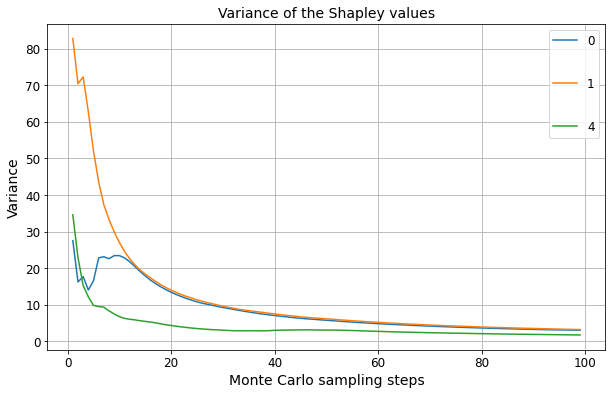

In [5]:
data_indices = [0, 1, 4]

all_sample_variances = []

for data_index in data_indices:
    V_j_plus_hausdorff_batches_per_atom = None
    V_j_minus_hausdorff_batches_per_atom = None
    V_random_hausdorff_batches_per_atom = None

    with open(f"../results/cumulative_computations/V_j_plus_hausdorff_batches_per_atom_{M}_{data_index}.pkl", "rb") as f:
        V_j_plus_hausdorff_batches_per_atom = pickle.load(f)
    with open(f"../results/cumulative_computations/V_j_minus_hausdorff_batches_per_atom_{M}_{data_index}.pkl", "rb") as f:
        V_j_minus_hausdorff_batches_per_atom = pickle.load(f)
    with open(f"../results/cumulative_computations/V_random_hausdorff_batches_per_atom_{M}_{data_index}.pkl", "rb") as f:
        V_random_hausdorff_batches_per_atom = pickle.load(f)

    # Compute cumulative sums of the values in V_j_plus_hausdorff_batches_per_atom
    cumulative_sums_j_plus = [0] * len(V_j_plus_hausdorff_batches_per_atom)
    cumulative_sums_j_minus = [0] * len(V_j_plus_hausdorff_batches_per_atom)
    for i in range(len(V_j_plus_hausdorff_batches_per_atom)):
        cumulative_sums_j_plus[i] = []
        for j in range(1, len(V_j_plus_hausdorff_batches_per_atom[i]) + 1):
            cumulative_sums_j_plus[i].append(sum(V_j_plus_hausdorff_batches_per_atom[i][:j]))
        cumulative_sums_j_minus[i] = []
        for j in range(1, len(V_j_minus_hausdorff_batches_per_atom[i]) + 1):
            cumulative_sums_j_minus[i].append(sum(V_j_minus_hausdorff_batches_per_atom[i][:j]))

    # Compute the elementwise differences between V_j_plus_hausdorff_batches_per_atom and V_j_minus_hausdorff_batches_per_atom
    maginal_contributions = [0] * len(cumulative_sums_j_plus)
    for i in range(len(cumulative_sums_j_plus)):
        maginal_contributions[i] = []
        for j in range(len(cumulative_sums_j_plus[i])):
            maginal_contributions[i].append((cumulative_sums_j_plus[i][j] - cumulative_sums_j_minus[i][j]) / (j + 1))

    phi_sums_over_M = [0] * M  # sum over the columns
    for i in range(len(maginal_contributions)):
        for j in range(len(maginal_contributions[i])):
            phi_sums_over_M[j] += maginal_contributions[i][j]

    # Compute the sample variance for phi_sums_over_M
    sample_variances = [0] * M
    for i in range(M):
        sample_variances[i] = torch.var(torch.tensor(phi_sums_over_M[:i + 1]), unbiased=True).item()

    all_sample_variances.append(sample_variances)

# Plot the sample variance for all data indices in a single plot
plt.figure(figsize=(10, 6))
plt.rc('axes', labelsize=14)  # Set font size for axes labels
plt.rc('xtick', labelsize=12)  # Set font size for x-axis ticks
plt.rc('ytick', labelsize=12)  # Set font size for y-axis ticks

for idx, sample_variances in zip(data_indices, all_sample_variances):
    plt.plot(range(len(sample_variances)), sample_variances, label=f"Data Index {idx}")

plt.title('Variance of the Shapley values', fontsize=14)
plt.xlabel('Monte Carlo sampling steps')
plt.ylabel('Variance')
custom_legend_names = ["                      " for idx in data_indices]
plt.legend(custom_legend_names, labelspacing=2.5, loc='upper right', fontsize=12)
custom_legend_names = [idx for idx in data_indices]
plt.legend(custom_legend_names, labelspacing=2.5, loc='upper right', fontsize=12)

plt.grid(True)
plt.savefig(f"{folder_save_path}/shapley_value_variance_exemplary_samples_{M}.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{folder_save_path}/shapley_value_variance_exemplary_samples_{M}.pdf", dpi=300, bbox_inches='tight')
plt.show()